
## Assignment 1: Data Science Salary Prediction (US/CANADA only)
By: Syed Shaheryar Haider

Date: Dec 6th 2025

## Framing the Problem

**Problem Statement:** Predicting salaries in the data science field is a highly relevant problem due to rapid growth in AI, analytics, and cloud technologies. Salary expectations vary widely based on job title, experience, company size, and location, making it difficult for both employers and job seekers to make informed decisions.
This project aims to build a regression model that predicts the annual salary of data-related roles in the United States and Canada using historical compensation data.

**Use case:** A practical use case for this model is career and compensation insights for individuals considering or negotiating data science roles in North America. By entering attributes such as job title, experience level, employment type, and remote ratio, a user can receive a realistic estimate of expected salary based on trends from thousands of industry records. Businesses can also use the model to set competitive salaries, identify pay disparities, and forecast hiring costs. Overall, the use case centers on salary prediction for decision support.

Since we are predicting a continuous numerical value (salary in USD), this is a supervised regression problem. We train our model on historical job salary data where the true salary is known, then predict salaries for new job profiles.


## DataSet

**Selected Dataset:** DataScience Job Salaries

**URL:** https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries 

The dataset used in this project is the Data Science Job Salaries dataset from Kaggle. It contains salary records across various data-related roles, including Data Scientist, Data Engineer, ML Engineer, and Analyst roles. Each row includes features such as experience level, employment type, job title, employee residence, company location, and salary in USD. For this assignment, the data is filtered to only include US and Canadian positions, ensuring salary predictions are specific to the North American job market.


In [4]:
# Import libraries  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

## Data Exploration



In [5]:
# Load the data

df = pd.read_csv('ds_salaries.csv')

print("="*80)
print("ORIGINAL DATASET INFORMATION")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Display column information
print("\nColumn Information:")
print(df.info())

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'ds_salaries.csv'

In [ ]:
print("\n" + "="*80)
print("DATA DESCRIPTION")
print("="*80)

# Check unique values for each column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Display value counts for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\n" + "-"*80)
print("CATEGORICAL VARIABLE DISTRIBUTIONS")
print("-"*80)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))  # Show top 10 only
    print(f"Total unique: {df[col].nunique()}")

# Check salary distribution
print("\n" + "-"*80)
print("SALARY DISTRIBUTION (BEFORE FILTERING)")
print("-"*80)
print(df['salary_in_usd'].describe())

# Check geographic distribution
if 'employee_residence' in df.columns:
    print("\n" + "-"*80)
    print("EMPLOYEE RESIDENCE - ALL COUNTRIES")
    print("-"*80)
    print(df['employee_residence'].value_counts())

if 'company_location' in df.columns:
    print("\n" + "-"*80)
    print("COMPANY LOCATION - ALL COUNTRIES")
    print("-"*80)
    print(df['company_location'].value_counts())


DATA DESCRIPTION

Unique values per column:
Unnamed: 0: 607 unique values
work_year: 3 unique values
experience_level: 4 unique values
employment_type: 4 unique values
job_title: 50 unique values
salary: 272 unique values
salary_currency: 17 unique values
salary_in_usd: 369 unique values
employee_residence: 57 unique values
remote_ratio: 3 unique values
company_location: 50 unique values
company_size: 3 unique values

--------------------------------------------------------------------------------
CATEGORICAL VARIABLE DISTRIBUTIONS
--------------------------------------------------------------------------------

experience_level:
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64
Total unique: 4

employment_type:
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64
Total unique: 4

job_title:
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engin

In [ ]:
print("\n" + "="*80)
print("FILTERING TO US/CANADA MARKET")
print("="*80)

# Strategy: Filter where BOTH employee_residence AND company_location are US or CA
# This ensures we're truly focusing on the North American market

if 'employee_residence' in df.columns and 'company_location' in df.columns:
    print("\nFiltering strategy: Both employee AND company must be in US/CA")
    
    # Count before filtering
    print(f"\nOriginal dataset: {len(df)} rows")
    
    # Filter where both are US or CA
    df_filtered = df[
        (df['employee_residence'].isin(['US', 'CA'])) & 
        (df['company_location'].isin(['US', 'CA']))
    ].copy()
    
    print(f"After filtering: {len(df_filtered)} rows")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    print(f"Percentage retained: {len(df_filtered)/len(df)*100:.2f}%")
    
    # Show distribution after filtering
    print("\n" + "-"*80)
    print("EMPLOYEE RESIDENCE (After filtering):")
    print(df_filtered['employee_residence'].value_counts())
    
    print("\nCOMPANY LOCATION (After filtering):")
    print(df_filtered['company_location'].value_counts())
    
elif 'employee_residence' in df.columns:
    print("\nFiltering by employee_residence only")
    
    # Count before filtering
    us_ca_count = df[df['employee_residence'].isin(['US', 'CA'])].shape[0]
    print(f"\nRows with US/CA in 'employee_residence': {us_ca_count}")
    print(f"Percentage of total: {us_ca_count/len(df)*100:.2f}%")
    
    # Filter the dataset
    df_filtered = df[df['employee_residence'].isin(['US', 'CA'])].copy()
    
    print(f"\n Filtered dataset created")
    print(f"Original rows: {len(df)}")
    print(f"Filtered rows: {len(df_filtered)}")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    
    # Distribution after filtering
    print(f"\nCountry distribution after filtering:")
    print(df_filtered['employee_residence'].value_counts())
    
elif 'company_location' in df.columns:
    print("\nFiltering by company_location only")
    
    # Count before filtering
    us_ca_count = df[df['company_location'].isin(['US', 'CA'])].shape[0]
    print(f"\nRows with US/CA in 'company_location': {us_ca_count}")
    print(f"Percentage of total: {us_ca_count/len(df)*100:.2f}%")
    
    # Filter the dataset
    df_filtered = df[df['company_location'].isin(['US', 'CA'])].copy()
    
    print(f"\n Filtered dataset created")
    print(f"Original rows: {len(df)}")
    print(f"Filtered rows: {len(df_filtered)}")
    print(f"Rows removed: {len(df) - len(df_filtered)}")
    
    # Distribution after filtering
    print(f"\nCountry distribution after filtering:")
    print(df_filtered['company_location'].value_counts())
    
else:
    print("Warning: No suitable location column found for filtering")
    df_filtered = df.copy()

# Verify the filtering worked
print("\n" + "="*80)
print("FILTERING VERIFICATION")
print("="*80)

if 'employee_residence' in df_filtered.columns:
    unique_countries = df_filtered['employee_residence'].unique()
    print(f"\nUnique countries in employee_residence: {unique_countries}")
    if set(unique_countries) - {'US', 'CA'}:
        print("WARNING: Found countries other than US/CA!")
        print(f"Unexpected countries: {set(unique_countries) - {'US', 'CA'}}")
    else:
        print("Only US and CA present in employee_residence")

if 'company_location' in df_filtered.columns:
    unique_countries = df_filtered['company_location'].unique()
    print(f"\nUnique countries in company_location: {unique_countries}")
    if set(unique_countries) - {'US', 'CA'}:
        print("WARNING: Found countries other than US/CA!")
        print(f"Unexpected countries: {set(unique_countries) - {'US', 'CA'}}")
    else:
        print("Only US and CA present in company_location")


FILTERING TO US/CANADA MARKET

Filtering strategy: Both employee AND company must be in US/CA

Original dataset: 607 rows
After filtering: 360 rows
Rows removed: 247
Percentage retained: 59.31%

--------------------------------------------------------------------------------
EMPLOYEE RESIDENCE (After filtering):
employee_residence
US    331
CA     29
Name: count, dtype: int64

COMPANY LOCATION (After filtering):
company_location
US    331
CA     29
Name: count, dtype: int64

FILTERING VERIFICATION

Unique countries in employee_residence: ['US' 'CA']
Only US and CA present in employee_residence

Unique countries in company_location: ['US' 'CA']
Only US and CA present in company_location


In [ ]:
print("\n" + "="*80)
print("FILTERED DATASET QUALITY CHECKS")
print("="*80)

# Check for duplicates
duplicates = df_filtered.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Check for missing values
print("\nMissing values in filtered data:")
missing = df_filtered.isnull().sum()
if missing.sum() == 0:
    print("No missing values found")
else:
    print(missing[missing > 0])

# Salary statistics after filtering
print("\n" + "-"*80)
print("SALARY STATISTICS (US/CANADA ONLY)")
print("-"*80)
print(df_filtered['salary_in_usd'].describe())

# Check for potential outliers using IQR method
Q1 = df_filtered['salary_in_usd'].quantile(0.25)
Q3 = df_filtered['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_filtered[
    (df_filtered['salary_in_usd'] < lower_bound) |
    (df_filtered['salary_in_usd'] > upper_bound)
]

print(f"\nPotential outliers (using IQR method): {len(outliers)}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

if len(outliers) > 0:
    print("\nOutlier salary range:")
    print(f"Min: ${outliers['salary_in_usd'].min():,.2f}")
    print(f"Max: ${outliers['salary_in_usd'].max():,.2f}")



FILTERED DATASET QUALITY CHECKS

Duplicate rows: 0

Missing values in filtered data:
No missing values found

--------------------------------------------------------------------------------
SALARY STATISTICS (US/CANADA ONLY)
--------------------------------------------------------------------------------
count       360.000000
mean     144988.669444
std       67998.038269
min       25000.000000
25%      100000.000000
50%      135000.000000
75%      170000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

Potential outliers (using IQR method): 11
Lower bound: $-5,000.00
Upper bound: $275,000.00

Outlier salary range:
Min: $276,000.00
Max: $600,000.00


In [ ]:
# Save to new CSV file
output_file = 'ds_salaries_us_canada.csv'
df_filtered.to_csv(output_file, index=False)
print(f"\n Filtered dataset saved to '{output_file}'")


 Filtered dataset saved to 'ds_salaries_us_canada.csv'


# Using the new and refined dataset - Explorarory Data Analysis

In [ ]:
df_usca = pd.read_csv('ds_salaries_us_canada.csv')

print("="*80)
print("EXPLORATORY DATA ANALYSIS - US/CANADA DATA SCIENCE SALARIES")
print("="*80)
print(f"\nDataset: ds_salaries_us_canada.csv")
print(f"Dataframe name: df_usca")
print(f"Shape: {df_usca.shape}")
print(f"Countries: US and Canada only\n")

# Verify we only have US/CA
if 'employee_residence' in df_usca.columns:
    unique_countries = df_usca['employee_residence'].unique()
    print(f"Verification - Countries in employee_residence: {unique_countries}")

if 'company_location' in df_usca.columns:
    unique_countries = df_usca['company_location'].unique()
    print(f"Verification - Countries in company_location: {unique_countries}")

EXPLORATORY DATA ANALYSIS - US/CANADA DATA SCIENCE SALARIES

Dataset: ds_salaries_us_canada.csv
Dataframe name: df_usca
Shape: (360, 12)
Countries: US and Canada only

Verification - Countries in employee_residence: ['US' 'CA']
Verification - Countries in company_location: ['US' 'CA']



UNIVARIATE ANALYSIS: SALARY

Salary Statistics (US/Canada only):
Mean: $144,988.67
Median: $135,000.00
Std Dev: $67,998.04
Min: $25,000.00
Max: $600,000.00
Range: $575,000.00

Salary Percentiles:
10th percentile: $78,791.00
25th percentile: $100,000.00
50th percentile: $135,000.00
75th percentile: $170,000.00
90th percentile: $214,130.00
95th percentile: $242,095.00
99th percentile: $418,870.00

Skewness: 2.236
Kurtosis: 9.088
→ Distribution is highly right-skewed (consider log transformation)


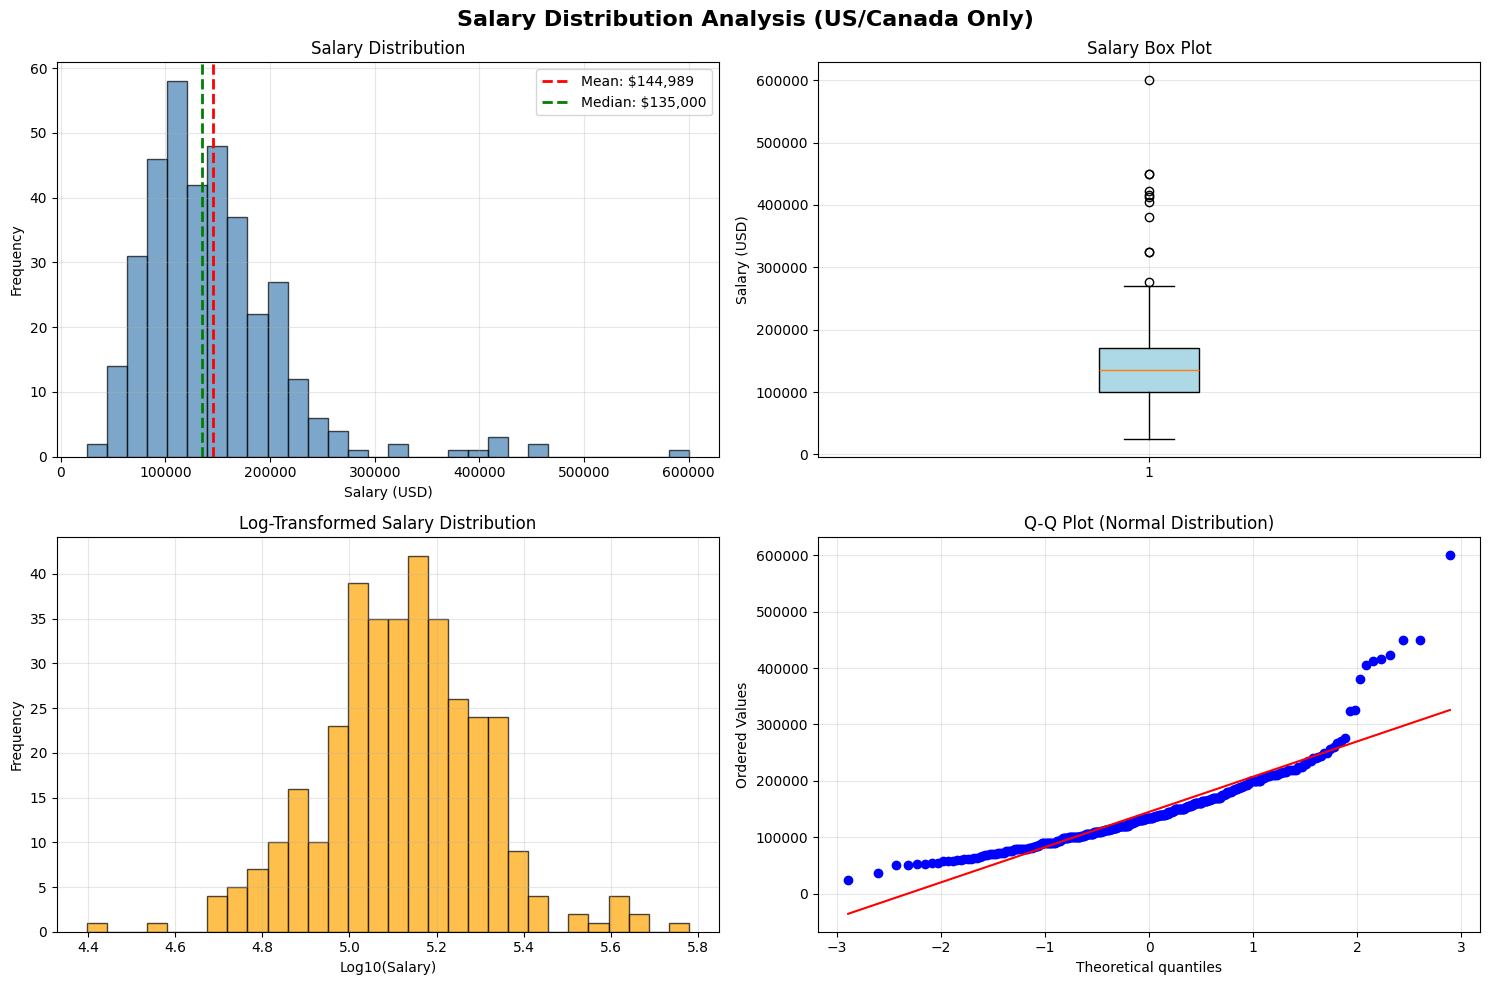

In [ ]:
print("\n" + "="*80)
print("UNIVARIATE ANALYSIS: SALARY")
print("="*80)

# Statistical summary
print("\nSalary Statistics (US/Canada only):")
print(f"Mean: ${df_usca['salary_in_usd'].mean():,.2f}")
print(f"Median: ${df_usca['salary_in_usd'].median():,.2f}")
print(f"Std Dev: ${df_usca['salary_in_usd'].std():,.2f}")
print(f"Min: ${df_usca['salary_in_usd'].min():,.2f}")
print(f"Max: ${df_usca['salary_in_usd'].max():,.2f}")
print(f"Range: ${df_usca['salary_in_usd'].max() - df_usca['salary_in_usd'].min():,.2f}")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nSalary Percentiles:")
for p in percentiles:
    value = df_usca['salary_in_usd'].quantile(p/100)
    print(f"{p}th percentile: ${value:,.2f}")

# Check for skewness and kurtosis
skewness = df_usca['salary_in_usd'].skew()
kurtosis = df_usca['salary_in_usd'].kurtosis()
print(f"\nSkewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

if skewness > 1:
    print("→ Distribution is highly right-skewed (consider log transformation)")
elif skewness > 0.5:
    print("→ Distribution is moderately right-skewed")
else:
    print("→ Distribution is approximately symmetric")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Salary Distribution Analysis (US/Canada Only)', fontsize=16, fontweight='bold')

# 1. Histogram
axes[0, 0].hist(df_usca['salary_in_usd'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_usca['salary_in_usd'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: ${df_usca["salary_in_usd"].mean():,.0f}')
axes[0, 0].axvline(df_usca['salary_in_usd'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: ${df_usca["salary_in_usd"].median():,.0f}')
axes[0, 0].set_xlabel('Salary (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Salary Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
box = axes[0, 1].boxplot(df_usca['salary_in_usd'], vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Salary (USD)')
axes[0, 1].set_title('Salary Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Log-transformed histogram
axes[1, 0].hist(np.log10(df_usca['salary_in_usd']), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Log10(Salary)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Log-Transformed Salary Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot
stats.probplot(df_usca['salary_in_usd'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Distribution)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('usca_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("\n" + "-"*80)
print("Categorical Features Analysis")
print("-"*80)

categorical_cols = ['experience_level', 'employment_type', 'company_size', 
                   'employee_residence', 'remote_ratio']
categorical_cols = [col for col in categorical_cols if col in df_usca.columns]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_usca[col].value_counts())
    
    # Statistical test
    if df_usca[col].nunique() > 1:
        groups = [df_usca[df_usca[col] == cat]['salary_in_usd'].values 
                  for cat in df_usca[col].unique()]
        f_stat, p_value = stats.f_oneway(*groups)
        
        if p_value < 0.05:
            print(f"→ {col} has SIGNIFICANT effect on salary (p={p_value:.4f})")
        else:
            print(f"→ {col} does NOT have significant effect (p={p_value:.4f})")

# Visualize salary by key features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Salary by Categorical Features (US/Canada)', fontsize=16, fontweight='bold')

plot_cols = ['experience_level', 'employment_type', 'company_size', 'employee_residence']
plot_cols = [col for col in plot_cols if col in df_usca.columns]

for idx, col in enumerate(plot_cols[:4]):
    row = idx // 2
    col_idx = idx % 2
    sns.boxplot(data=df_usca, x=col, y='salary_in_usd', ax=axes[row, col_idx], palette='Set2')
    axes[row, col_idx].set_title(f'Salary by {col}')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
    axes[row, col_idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('02_salary_by_categories.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: 02_salary_by_categories.png")


--------------------------------------------------------------------------------
Categorical Features Analysis
--------------------------------------------------------------------------------


NameError: name 'df_usca' is not defined

## Feature Analysis + Correlation Matrix


CORRELATION ANALYSIS

Correlation Matrix:
               Unnamed: 0  work_year    salary  salary_in_usd  remote_ratio
Unnamed: 0       1.000000   0.849892 -0.058698      -0.056441     -0.002051
work_year        0.849892   1.000000 -0.075029      -0.071711     -0.046704
salary          -0.058698  -0.075029  1.000000       0.983712      0.064346
salary_in_usd   -0.056441  -0.071711  0.983712       1.000000      0.068984
remote_ratio    -0.002051  -0.046704  0.064346       0.068984      1.000000


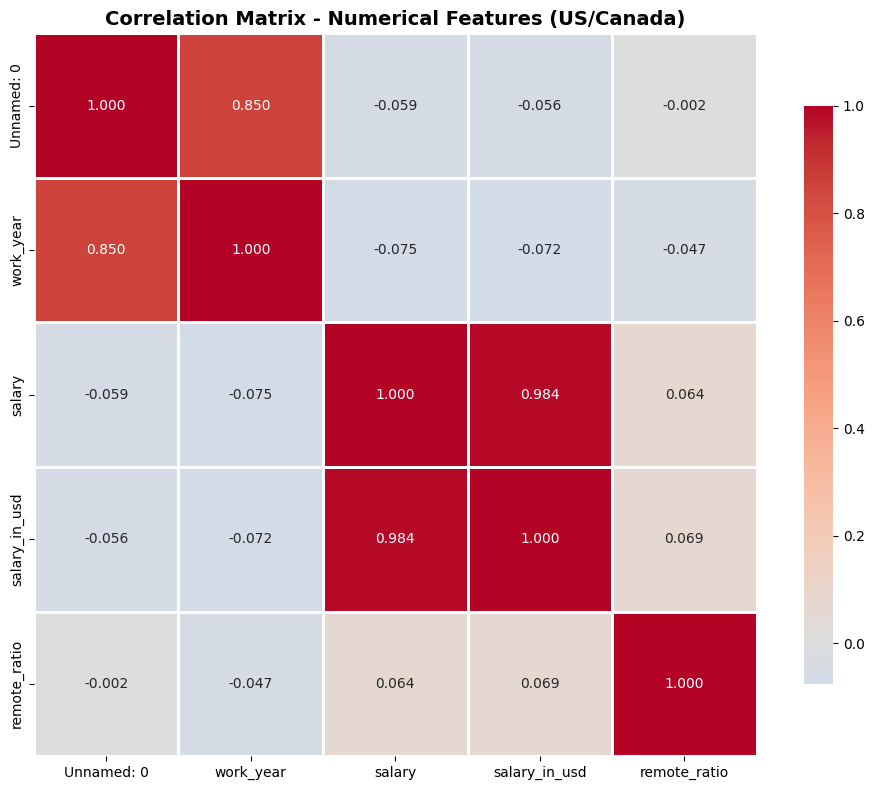


Saved: usca_correlation_matrix.png

Correlation with Salary (sorted):
salary_in_usd    1.000000
salary           0.983712
remote_ratio     0.068984
Unnamed: 0      -0.056441
work_year       -0.071711
Name: salary_in_usd, dtype: float64


In [ ]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select numerical columns only
numerical_df = df_usca.select_dtypes(include=[np.number])

if numerical_df.shape[1] > 1:
    # Correlation matrix
    correlation_matrix = numerical_df.corr()
    
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Visualize correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
    plt.title('Correlation Matrix - Numerical Features (US/Canada)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('usca_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Correlation with target
    print("\nCorrelation with Salary (sorted):")
    salary_corr = correlation_matrix['salary_in_usd'].sort_values(ascending=False)
    print(salary_corr)
else:
    print("\nInsufficient numerical features for correlation analysis")

## Feature Engineering


In [ ]:
# Create copy for feature engineering
df_fe_usca = df_usca.copy()

print(f"\nStarting shape: {df_fe_usca.shape}")

# ------------------------------------------------------------------------------
# 3.1 Experience Level Features
# ------------------------------------------------------------------------------

print("\n" + "-"*80)
print("Creating Experience Level Features")
print("-"*80)

if 'experience_level' in df_fe_usca.columns:
    df_fe_usca['is_entry_level'] = (df_fe_usca['experience_level'] == 'EN').astype(int)
    df_fe_usca['is_mid_level'] = (df_fe_usca['experience_level'] == 'MI').astype(int)
    df_fe_usca['is_senior_level'] = (df_fe_usca['experience_level'] == 'SE').astype(int)
    df_fe_usca['is_executive_level'] = (df_fe_usca['experience_level'] == 'EX').astype(int)
    
    experience_map = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
    df_fe_usca['experience_level_ordinal'] = df_fe_usca['experience_level'].map(experience_map)
    
    print("Created: Binary indicators + ordinal encoding")


Starting shape: (360, 12)

--------------------------------------------------------------------------------
Creating Experience Level Features
--------------------------------------------------------------------------------
Created: Binary indicators + ordinal encoding


In [ ]:
print("\n" + "-"*80)
print("Creating Employment Type Features")
print("-"*80)

if 'employment_type' in df_fe_usca.columns:
    df_fe_usca['is_full_time'] = (df_fe_usca['employment_type'] == 'FT').astype(int)
    df_fe_usca['is_part_time'] = (df_fe_usca['employment_type'] == 'PT').astype(int)
    df_fe_usca['is_contract'] = (df_fe_usca['employment_type'] == 'CT').astype(int)
    df_fe_usca['is_freelance'] = (df_fe_usca['employment_type'] == 'FL').astype(int)
    
    print("Created: Employment type binary indicators")


--------------------------------------------------------------------------------
Creating Employment Type Features
--------------------------------------------------------------------------------
Created: Employment type binary indicators


In [ ]:
print("\n" + "-"*80)
print("Creating Remote Work Features")
print("-"*80)

if 'remote_ratio' in df_fe_usca.columns:
    df_fe_usca['is_fully_remote'] = (df_fe_usca['remote_ratio'] == 100).astype(int)
    df_fe_usca['is_hybrid'] = (df_fe_usca['remote_ratio'] == 50).astype(int)
    df_fe_usca['is_onsite'] = (df_fe_usca['remote_ratio'] == 0).astype(int)
    df_fe_usca['remote_ratio_normalized'] = df_fe_usca['remote_ratio'] / 100
    
    print("Created: Remote work indicators + normalized ratio")


--------------------------------------------------------------------------------
Creating Remote Work Features
--------------------------------------------------------------------------------
Created: Remote work indicators + normalized ratio


In [ ]:

print("\n" + "-"*80)
print("Creating Company Size Features")
print("-"*80)

if 'company_size' in df_fe_usca.columns:
    df_fe_usca['is_small_company'] = (df_fe_usca['company_size'] == 'S').astype(int)
    df_fe_usca['is_medium_company'] = (df_fe_usca['company_size'] == 'M').astype(int)
    df_fe_usca['is_large_company'] = (df_fe_usca['company_size'] == 'L').astype(int)
    
    company_size_map = {'S': 1, 'M': 2, 'L': 3}
    df_fe_usca['company_size_ordinal'] = df_fe_usca['company_size'].map(company_size_map)
    
    print("Created: Company size indicators + ordinal encoding")


--------------------------------------------------------------------------------
Creating Company Size Features
--------------------------------------------------------------------------------
Created: Company size indicators + ordinal encoding


In [ ]:
print("\n" + "-"*80)
print("Creating Location Features")
print("-"*80)

if 'employee_residence' in df_fe_usca.columns:
    df_fe_usca['is_us_based'] = (df_fe_usca['employee_residence'] == 'US').astype(int)
    df_fe_usca['is_canada_based'] = (df_fe_usca['employee_residence'] == 'CA').astype(int)
    
    print(f"  Created: Location indicators")
    print(f"  US-based: {df_fe_usca['is_us_based'].sum()}")
    print(f"  Canada-based: {df_fe_usca['is_canada_based'].sum()}")


--------------------------------------------------------------------------------
Creating Location Features
--------------------------------------------------------------------------------
  Created: Location indicators
  US-based: 331
  Canada-based: 29


In [ ]:
print("\n" + "-"*80)
print("Creating Job Title Features")
print("-"*80)

if 'job_title' in df_fe_usca.columns:
    job_title_lower = df_fe_usca['job_title'].str.lower()
    
    df_fe_usca['is_data_scientist'] = job_title_lower.str.contains('data scientist', na=False).astype(int)
    df_fe_usca['is_data_engineer'] = job_title_lower.str.contains('data engineer', na=False).astype(int)
    df_fe_usca['is_data_analyst'] = job_title_lower.str.contains('data analyst|analyst', na=False).astype(int)
    df_fe_usca['is_ml_engineer'] = job_title_lower.str.contains('machine learning|ml engineer', na=False).astype(int)
    df_fe_usca['is_manager'] = job_title_lower.str.contains('manager|lead|head|director', na=False).astype(int)
    
    df_fe_usca['title_has_senior'] = job_title_lower.str.contains('senior|sr', na=False).astype(int)
    df_fe_usca['title_has_junior'] = job_title_lower.str.contains('junior|jr', na=False).astype(int)
    df_fe_usca['title_has_lead'] = job_title_lower.str.contains('lead|principal|staff', na=False).astype(int)
    
    print("Created: Job role and seniority indicators")


--------------------------------------------------------------------------------
Creating Job Title Features
--------------------------------------------------------------------------------
Created: Job role and seniority indicators


In [ ]:
print("\n" + "-"*80)
print("Creating Temporal Features")
print("-"*80)

if 'work_year' in df_fe_usca.columns:
    min_year = df_fe_usca['work_year'].min()
    max_year = df_fe_usca['work_year'].max()
    
    df_fe_usca['years_since_start'] = df_fe_usca['work_year'] - min_year
    df_fe_usca['is_recent_year'] = (df_fe_usca['work_year'] >= max_year - 1).astype(int)
    
    print(f"Created: Temporal features (range: {min_year}-{max_year})")


--------------------------------------------------------------------------------
Creating Temporal Features
--------------------------------------------------------------------------------
Created: Temporal features (range: 2020-2022)


In [ ]:
print("\n" + "-"*80)
print("Creating Interaction Features")
print("-"*80)

if 'experience_level_ordinal' in df_fe_usca.columns and 'company_size_ordinal' in df_fe_usca.columns:
    df_fe_usca['exp_company_interaction'] = df_fe_usca['experience_level_ordinal'] * df_fe_usca['company_size_ordinal']
    print("exp_company_interaction")

if 'experience_level_ordinal' in df_fe_usca.columns and 'remote_ratio_normalized' in df_fe_usca.columns:
    df_fe_usca['exp_remote_interaction'] = df_fe_usca['experience_level_ordinal'] * df_fe_usca['remote_ratio_normalized']
    print("exp_remote_interaction")

if 'is_senior_level' in df_fe_usca.columns and 'is_large_company' in df_fe_usca.columns:
    df_fe_usca['senior_large_company'] = df_fe_usca['is_senior_level'] * df_fe_usca['is_large_company']
    print("senior_large_company")


--------------------------------------------------------------------------------
Creating Interaction Features
--------------------------------------------------------------------------------
exp_company_interaction
exp_remote_interaction
senior_large_company



--------------------------------------------------------------------------------
Feature Correlation with Salary
--------------------------------------------------------------------------------

Top 15 features by correlation:
                          correlation  abs_correlation
salary                       0.983712         0.983712
exp_company_interaction      0.411510         0.411510
experience_level_ordinal     0.350957         0.350957
is_data_analyst             -0.309186         0.309186
is_executive_level           0.308617         0.308617
title_has_lead               0.254753         0.254753
is_entry_level              -0.230819         0.230819
exp_remote_interaction       0.217900         0.217900
senior_large_company         0.217224         0.217224
is_canada_based             -0.208814         0.208814
is_us_based                  0.208814         0.208814
company_size_ordinal         0.197734         0.197734
is_large_company             0.180910         0.180910
is

c:\Users\Shariq\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Shariq\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


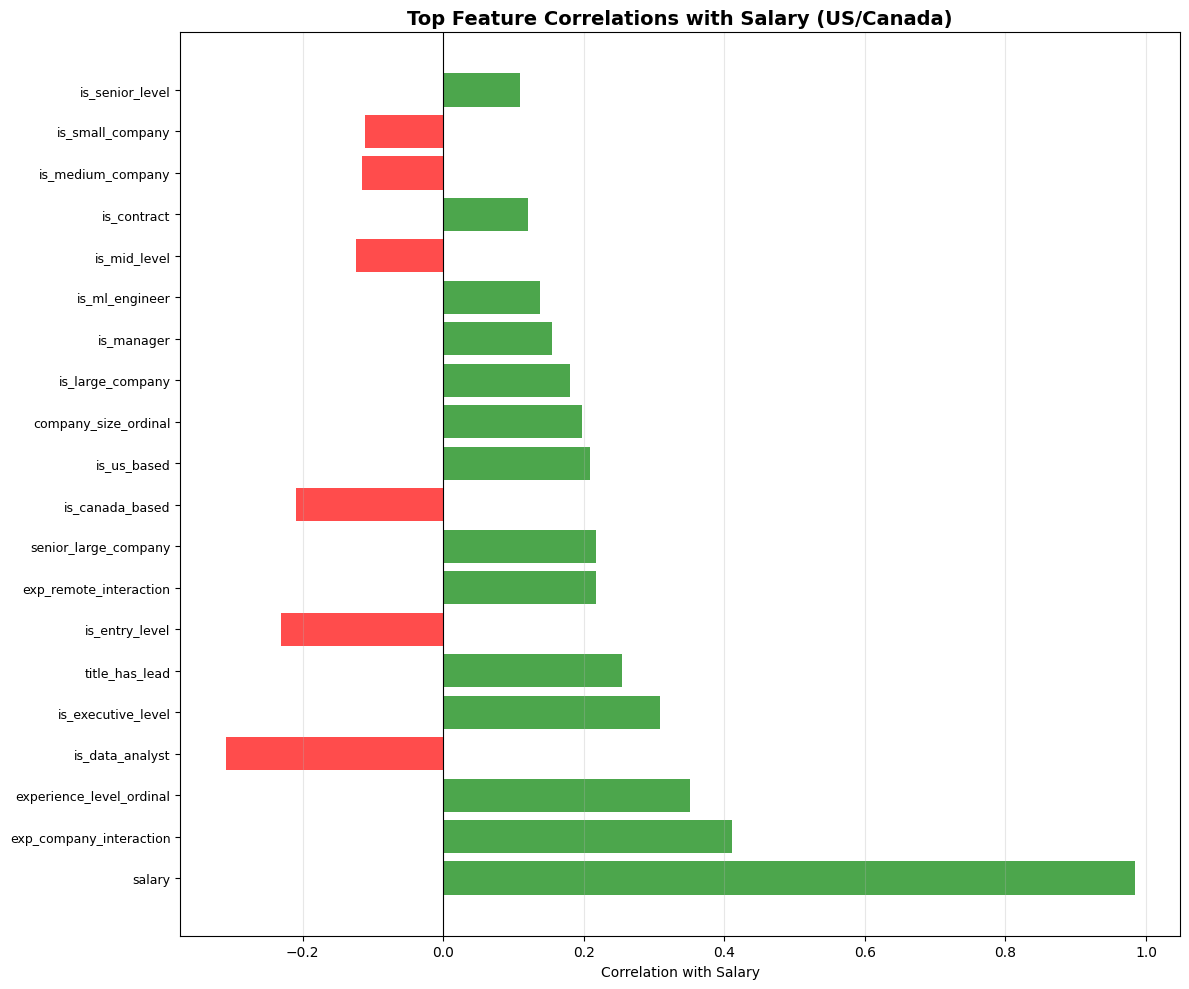

In [ ]:
print("\n" + "-"*80)
print("Feature Correlation with Salary")
print("-"*80)

numerical_features = df_fe_usca.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col != 'salary_in_usd']

correlations = {}
for feat in numerical_features:
    corr = df_fe_usca[feat].corr(df_fe_usca['salary_in_usd'])
    correlations[feat] = corr

correlations_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['correlation'])
correlations_df['abs_correlation'] = correlations_df['correlation'].abs()
correlations_df = correlations_df.sort_values('abs_correlation', ascending=False)

print("\nTop 15 features by correlation:")
print(correlations_df.head(15).to_string())

# Visualize
plt.figure(figsize=(12, 10))
top_n = min(20, len(correlations_df))
top_features = correlations_df.head(top_n)

colors = ['green' if x > 0 else 'red' for x in top_features['correlation']]
plt.barh(range(len(top_features)), top_features['correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index, fontsize=9)
plt.xlabel('Correlation with Salary')
plt.title('Top Feature Correlations with Salary (US/Canada)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('03_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Save engineered data
df_fe_usca.to_csv('ds_salaries_usca_engineered.csv', index=False)
print(f"\n Saved: ds_salaries_usca_engineered.csv")
print(f"Final shape: {df_fe_usca.shape}")
print(f"Features created: {df_fe_usca.shape[1] - df_usca.shape[1]}")


 Saved: ds_salaries_usca_engineered.csv
Final shape: (360, 44)
Features created: 32


## Model Development

In [ ]:
print("\n" + "-"*80)
print("Preparing Features for Modeling")
print("-"*80)

# Separate target
y = df_fe_usca['salary_in_usd'].copy()

# Drop non-feature columns
columns_to_drop = [
    'salary_in_usd', 'salary', 'salary_currency', 'job_title',
    'experience_level', 'employment_type', 'company_size', 
    'employee_residence', 'company_location'
]
columns_to_drop = [col for col in columns_to_drop if col in df_fe_usca.columns]

X = df_fe_usca.drop(columns=columns_to_drop)

# Ensure all numeric
X = X.select_dtypes(include=[np.number])

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target: {y.shape[0]}")


--------------------------------------------------------------------------------
Preparing Features for Modeling
--------------------------------------------------------------------------------
Features: 35
Samples: 360
Target: 360


In [ ]:
print("\n" + "-"*80)
print("Train-Test Split")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled")


--------------------------------------------------------------------------------
Train-Test Split
--------------------------------------------------------------------------------
Training: 252 samples (70.0%)
Test: 108 samples (30.0%)
Features scaled


In [ ]:
print("\n" + "-"*80)
print("Training Multiple Models")
print("-"*80)

# Model 1: Linear Regression
print("\n1. Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Ridge Regression
print("2. Ridge Regression (with GridSearchCV)...")
ridge = GridSearchCV(
    Ridge(), 
    {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, 
    cv=5, scoring='r2'
)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print(f"   Best alpha: {ridge.best_params_['alpha']}")

# Model 3: Random Forest
print("3. Random Forest (with GridSearchCV)...")
rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    cv=3, scoring='r2'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"   Best params: {rf.best_params_}")

# Model 4: Gradient Boosting
print("4. Gradient Boosting (with GridSearchCV)...")
gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=3, scoring='r2'
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"   Best params: {gb.best_params_}")



--------------------------------------------------------------------------------
Training Multiple Models
--------------------------------------------------------------------------------

1. Linear Regression...
2. Ridge Regression (with GridSearchCV)...
   Best alpha: 100
3. Random Forest (with GridSearchCV)...
   Best params: {'max_depth': 10, 'n_estimators': 100}
4. Gradient Boosting (with GridSearchCV)...
   Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}



--------------------------------------------------------------------------------
Model Performance Comparison
--------------------------------------------------------------------------------

            Model         RMSE          MAE       R²
Linear Regression 50681.646526 38083.057260 0.251892
 Ridge Regression 46683.043661 35875.859612 0.365282
    Random Forest 54949.227038 40592.272987 0.120601
Gradient Boosting 52726.093375 37825.573363 0.190319

 Best Model: Ridge Regression
   R²: 0.3653
   RMSE: $46,683.04
   MAE: $35,875.86


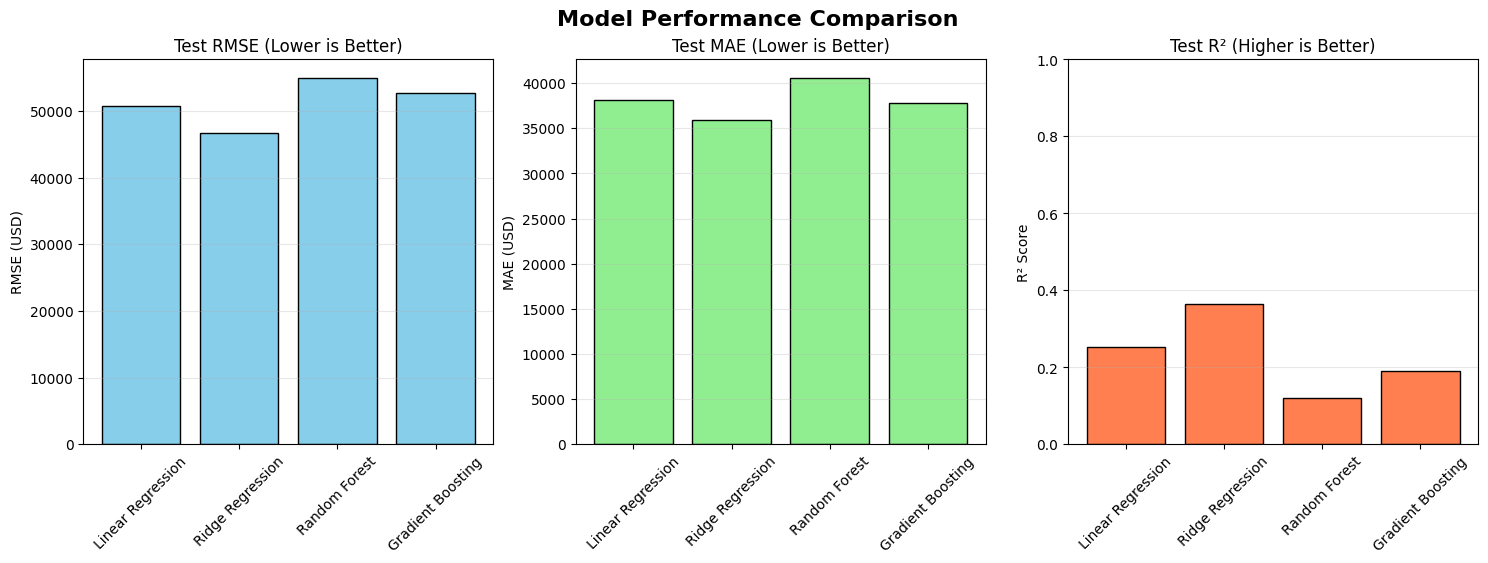

In [ ]:
print("\n" + "-"*80)
print("Model Performance Comparison")
print("-"*80)

models = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

results = []
for name, y_pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

# Find best model
best_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n Best Model: {best_model_name}")
print(f"   R²: {results_df.loc[best_idx, 'R²']:.4f}")
print(f"   RMSE: ${results_df.loc[best_idx, 'RMSE']:,.2f}")
print(f"   MAE: ${results_df.loc[best_idx, 'MAE']:,.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

axes[0].bar(results_df['Model'], results_df['RMSE'], color='skyblue', edgecolor='black')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_title('Test RMSE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(results_df['Model'], results_df['MAE'], color='lightgreen', edgecolor='black')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_title('Test MAE (Lower is Better)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].bar(results_df['Model'], results_df['R²'], color='coral', edgecolor='black')
axes[2].set_ylabel('R² Score')
axes[2].set_title('Test R² (Higher is Better)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')


DETAILED ANALYSIS: RIDGE REGRESSION


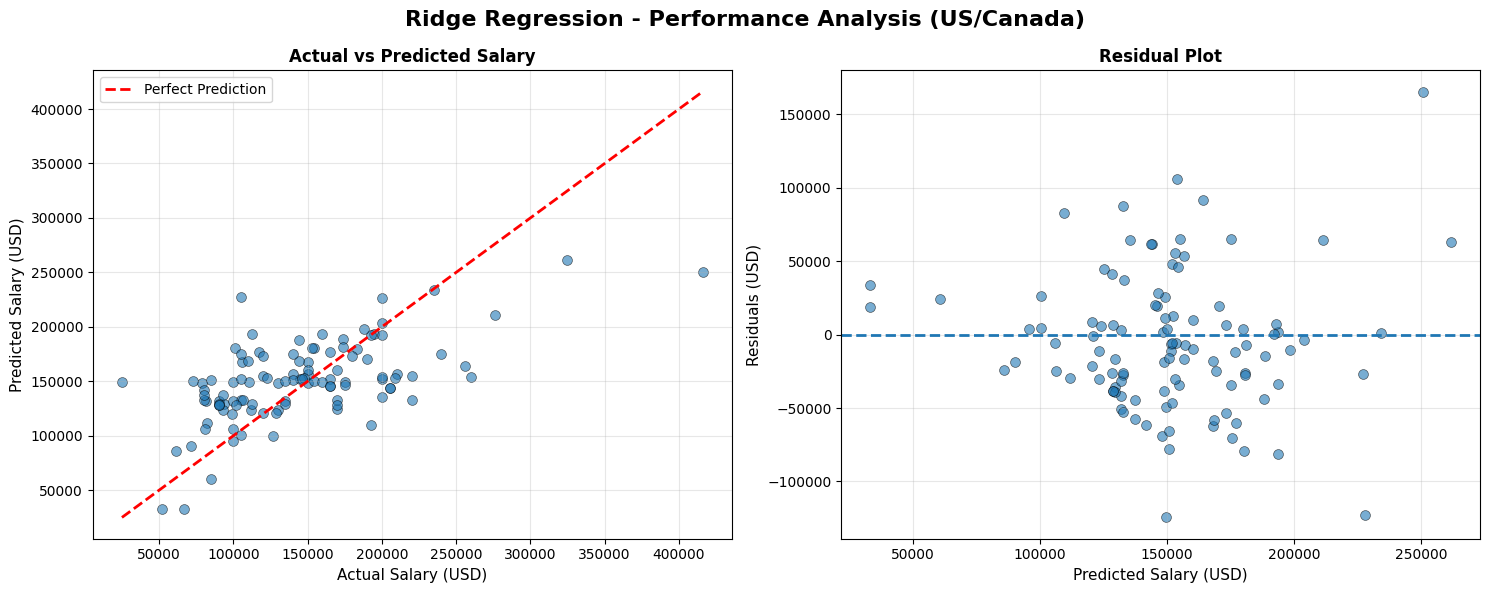


Residual Analysis:
Mean residual: $-5,956.67 (should be close to 0)
Std residual: $46,517.31
Min residual: $-124,481.01 (underprediction)
Max residual: $165,435.42 (overprediction)


In [ ]:
print("\n" + "="*80)
print(f"DETAILED ANALYSIS: {best_model_name.upper()}")
print("="*80)

# Select best predictions ONLY (no undefined model objects)
if best_model_name == 'Linear Regression':
    y_test_pred_best = y_pred_lr
elif best_model_name == 'Ridge Regression':
    y_test_pred_best = y_pred_ridge
elif best_model_name == 'Random Forest':
    y_test_pred_best = y_pred_rf
else:  # Gradient Boosting
    y_test_pred_best = y_pred_gb

# Actual vs Predicted & Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'{best_model_name} - Performance Analysis (US/Canada)', fontsize=16, fontweight='bold')

# --- Scatter Plot ---
axes[0].scatter(y_test, y_test_pred_best, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
axes[0].set_xlabel('Actual Salary (USD)', fontsize=11)
axes[0].set_ylabel('Predicted Salary (USD)', fontsize=11)
axes[0].set_title('Actual vs Predicted Salary', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Residual Plot ---
residuals = y_test - y_test_pred_best

axes[1].scatter(y_test_pred_best, residuals, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary (USD)', fontsize=11)
axes[1].set_ylabel('Residuals (USD)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('usca_best_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


# Residual Statistics
print("\nResidual Analysis:")
print(f"Mean residual: ${residuals.mean():,.2f} (should be close to 0)")
print(f"Std residual: ${residuals.std():,.2f}")
print(f"Min residual: ${residuals.min():,.2f} (underprediction)")
print(f"Max residual: ${residuals.max():,.2f} (overprediction)")

